# Decision Tree Regression

Decision Tree Regression is a supervised machine learning algorithm used to predict continuous numerical values.

### Import Library

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

### Load Dataset

In [45]:
df = pd.read_csv("../../Dataset/diabetes.csv")

### Dataset Information

In [46]:
df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,59.0,2.0,32.1,101.0,157.0,93.2,38.0,4.0,4.8598,87.0,151.0
1,48.0,1.0,21.6,87.0,183.0,103.2,70.0,3.0,3.8918,69.0,75.0
2,72.0,2.0,30.5,93.0,156.0,93.6,41.0,4.0,4.6728,85.0,141.0
3,24.0,1.0,25.3,84.0,198.0,131.4,40.0,5.0,4.8903,89.0,206.0
4,50.0,1.0,23.0,101.0,192.0,125.4,52.0,4.0,4.2905,80.0,135.0


In [47]:
df.shape

(442, 11)

In [48]:
df.columns

Index(['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6',
       'target'],
      dtype='str')

In [49]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
 10  target  442 non-null    float64
dtypes: float64(11)
memory usage: 38.1 KB


In [50]:
df.describe()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
count,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000
mean,48.518100,1.468326,26.375792,94.647014,189.140271,115.439140,49.788462,4.070249,4.641411,91.260181,152.133484
std,13.109028,0.499561,4.418122,13.831283,34.608052,30.413081,12.934202,1.290450,0.522391,11.496335,77.093005
min,19.000000,1.000000,18.000000,62.000000,97.000000,41.600000,22.000000,2.000000,3.258100,58.000000,25.000000
25%,38.250000,1.000000,23.200000,84.000000,164.250000,96.050000,40.250000,3.000000,4.276700,83.250000,87.000000
50%,50.000000,1.000000,25.700000,93.000000,186.000000,113.000000,48.000000,4.000000,4.620050,91.000000,140.500000
75%,59.000000,2.000000,29.275000,105.000000,209.750000,134.500000,57.750000,5.000000,4.997200,98.000000,211.500000
max,79.000000,2.000000,42.200000,133.000000,301.000000,242.400000,99.000000,9.090000,6.107000,124.000000,346.000000


In [51]:
df.isnull().sum()

age       0
sex       0
bmi       0
bp        0
s1        0
s2        0
s3        0
s4        0
s5        0
s6        0
target    0
dtype: int64

### Separate Features and Target

In [52]:
X = df.drop("target", axis=1)
y = df["target"]

print("Features:")
print(X.head())
print("\nTarget:")
print(y.head())

Features:
    age  sex   bmi     bp     s1     s2    s3   s4      s5    s6
0  59.0  2.0  32.1  101.0  157.0   93.2  38.0  4.0  4.8598  87.0
1  48.0  1.0  21.6   87.0  183.0  103.2  70.0  3.0  3.8918  69.0
2  72.0  2.0  30.5   93.0  156.0   93.6  41.0  4.0  4.6728  85.0
3  24.0  1.0  25.3   84.0  198.0  131.4  40.0  5.0  4.8903  89.0
4  50.0  1.0  23.0  101.0  192.0  125.4  52.0  4.0  4.2905  80.0

Target:
0    151.0
1     75.0
2    141.0
3    206.0
4    135.0
Name: target, dtype: float64


### Test-Train Split

In [53]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (353, 10)
Testing data: (89, 10)


In [54]:
train_data = X_train.copy()
train_data["target"] = y_train
correlation = train_data.corr()["target"].sort_values(ascending=False)
print(correlation)

target    1.000000
bmi       0.604751
s5        0.552183
bp        0.444770
s4        0.425094
s6        0.390363
s1        0.199547
age       0.196510
s2        0.154922
sex       0.007116
s3       -0.384000
Name: target, dtype: float64


### Feature Selection 

`sex` is reomved from the dataset

In [55]:
X_train = X_train.drop(columns=["sex"])
X_test = X_test.drop(columns=["sex"])
print("Training features:")
print(X_train.columns)
print("\nNumber of features:", X_train.shape[1])

Training features:
Index(['age', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6'], dtype='str')

Number of features: 9


### Model Training

In [56]:
tree = DecisionTreeRegressor(criterion="squared_error",  random_state=42)
tree.fit(X_train, y_train)
print("Baseline Decision Tree Regressor trained successfully.")

Baseline Decision Tree Regressor trained successfully.


### Baseline

In [57]:
y_pred = tree.predict(X_test)
comparison = pd.DataFrame({
    "Actual": y_test.to_numpy(),
    "Predicted": y_pred
})
display(comparison.head(15))

,Actual,Predicted
0,219.0,190.0
1,70.0,166.0
2,202.0,170.0
3,230.0,268.0
4,111.0,183.0
5,84.0,97.0
6,242.0,233.0
7,272.0,262.0
8,94.0,200.0
9,96.0,173.0


In [58]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Baseline Model Results")
print("MAE:", round(mae, 4))
print("MSE:", round(mse, 4))
print("RMSE:", round(rmse, 4))
print("R² Score:", round(r2, 4))

Baseline Model Results
MAE: 55.6966
MSE: 4900.4607
RMSE: 70.0033
R² Score: 0.0751


In [59]:
train_r2 = tree.score(X_train, y_train)
test_r2 = tree.score(X_test, y_test)

print("Training R²:", round(train_r2, 4))
print("Testing R²:", round(test_r2, 4))
print("R² Difference:", round(train_r2 - test_r2, 4))

Training R²: 1.0
Testing R²: 0.0751
R² Difference: 0.9249


### Hyperparameter tuning

In [60]:
param_grid = {
    "criterion": ["squared_error", "friedman_mse"],
    "max_depth": [2, 3, 4, 5, 6, 8, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "ccp_alpha": [0.0, 0.001, 0.01, 0.1]
}

In [61]:
tree = DecisionTreeRegressor(random_state=42)
grid = GridSearchCV(
    estimator=tree,
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    refit=True
)
grid.fit(X_train, y_train)
print("Grid Search Completed")

Grid Search Completed


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/model_selection/_validation.py:489: FitFailedWarning: 
1260 fits failed out of a total of 2520.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
694 fits failed with the following error:
Traceback (most recent call last):
  File "/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/model_selection/_validation.py", line 851, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/base.py", line 1393, in wrapper
    estimator._validate_params()
    ~~~~~~~~~~~~~~~~

In [62]:
print("Best Parameters:")
print(grid.best_params_)
print("\nBest Cross-Validation R²:")
print(round(grid.best_score_, 4))
best_tree = grid.best_estimator_
print("\nBest Model:")
print(best_tree)

Best Parameters:
{'ccp_alpha': 0.0, 'criterion': 'squared_error', 'max_depth': 2, 'min_samples_leaf': 1, 'min_samples_split': 2}

Best Cross-Validation R²:
0.3615

Best Model:
DecisionTreeRegressor(max_depth=2, random_state=42)


In [63]:
results = pd.DataFrame(grid.cv_results_)
results = results.sort_values(by="mean_test_score",ascending=False)
display(
    results[
        [
            "param_criterion",
            "param_max_depth",
            "param_min_samples_split",
            "param_min_samples_leaf",
            "param_ccp_alpha",
            "mean_test_score",
            "std_test_score"
        ]
    ].head(10)
)

,param_criterion,param_max_depth,param_min_samples_split,param_min_samples_leaf,param_ccp_alpha,mean_test_score,std_test_score
0,squared_error,2,2,1,0.000,0.361528,0.109612
126,squared_error,2,2,1,0.001,0.361528,0.109612
128,squared_error,2,10,1,0.001,0.361528,0.109612
129,squared_error,2,2,2,0.001,0.361528,0.109612
130,squared_error,2,5,2,0.001,0.361528,0.109612
131,squared_error,2,10,2,0.001,0.361528,0.109612
132,squared_error,2,2,4,0.001,0.361528,0.109612
133,squared_error,2,5,4,0.001,0.361528,0.109612
134,squared_error,2,10,4,0.001,0.361528,0.109612
1,squared_error,2,5,1,0.000,0.361528,0.109612


In [64]:
y_pred_tuned = best_tree.predict(X_test)
comparison = pd.DataFrame({
    "Actual": y_test.to_numpy(),
    "Predicted": y_pred_tuned
})
display(comparison.head(15))

,Actual,Predicted
0,219.0,164.666667
1,70.0,191.101695
2,202.0,164.666667
3,230.0,191.101695
4,111.0,100.559211
5,84.0,100.559211
6,242.0,271.076923
7,272.0,191.101695
8,94.0,164.666667
9,96.0,191.101695


In [65]:
mae = mean_absolute_error(y_test, y_pred_tuned)
mse = mean_squared_error(y_test, y_pred_tuned)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_tuned)

print("Tuned Decision Tree Regression Results")
print("MAE:", round(mae, 4))
print("MSE:", round(mse, 4))
print("RMSE:", round(rmse, 4))
print("R² Score:", round(r2, 4))
print("\nBest Cross-Validation R²:", round(grid.best_score_, 4))

Tuned Decision Tree Regression Results
MAE: 49.3653
MSE: 3735.4996
RMSE: 61.1187
R² Score: 0.2949

Best Cross-Validation R²: 0.3615


In [70]:
baseline_tree = DecisionTreeRegressor(criterion="squared_error", random_state=42)
baseline_tree.fit(X_train, y_train)
baseline_pred = baseline_tree.predict(X_test)
best_tree = grid.best_estimator_
y_pred_tuned = best_tree.predict(X_test)
baseline_results = {
    "Model": "Baseline",
    "MAE": mean_absolute_error(y_test, baseline_pred),
    "MSE": mean_squared_error(y_test, baseline_pred),
    "RMSE": np.sqrt(mean_squared_error(y_test, baseline_pred)),
    "R2": r2_score(y_test, baseline_pred)
}
tuned_results = {
    "Model": "Tuned",
    "MAE": mean_absolute_error(y_test, y_pred_tuned),
    "MSE": mean_squared_error(y_test, y_pred_tuned),
    "RMSE": np.sqrt(mean_squared_error(y_test, y_pred_tuned)),
    "R2": r2_score(y_test, y_pred_tuned)
}
results_comparison = pd.DataFrame([
    baseline_results,
    tuned_results
])
results_comparison.round(4)

,Model,MAE,MSE,RMSE,R2
0,Baseline,55.6966,4900.4607,70.0033,0.0751
1,Tuned,49.3653,3735.4996,61.1187,0.2949


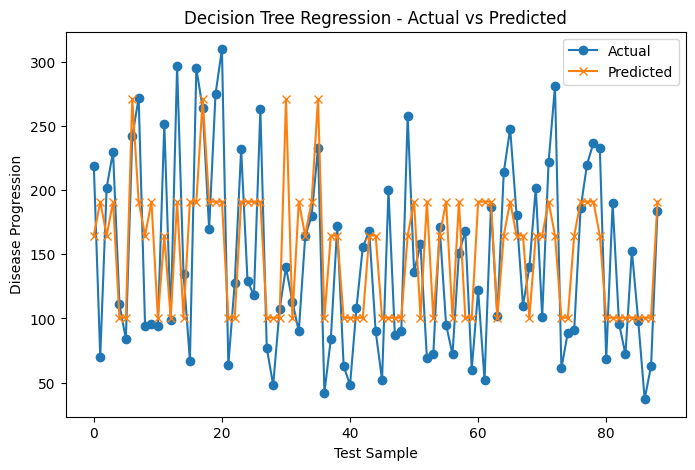

In [67]:
plt.figure(figsize=(8, 5))
plt.plot( y_test.to_numpy(), label="Actual",marker="o")
plt.plot(y_pred_tuned, label="Predicted", marker="x")
plt.xlabel("Test Sample")
plt.ylabel("Disease Progression")
plt.title("Decision Tree Regression - Actual vs Predicted")
plt.legend()
plt.show()

In [68]:
importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": best_tree.feature_importances_
}).sort_values(
    by="Importance",
    ascending=False
)

display(importance)

,Feature,Importance
1,bmi,0.822417
7,s5,0.177583
0,age,0.000000
2,bp,0.000000
3,s1,0.000000
4,s2,0.000000
5,s3,0.000000
6,s4,0.000000
8,s6,0.000000
